# 尖晶石获取

In [6]:
import os
import re
import pandas as pd
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
import warnings

def extract_elements(formula):
    elements = re.findall(r'[A-Z][a-z]?', formula)  # 提取元素
    return ", ".join(elements)

def get_materials_data(apikey="", force_update=False):
    filepath = '/home/gaotianjiao/modnet-master/ext_struc/spinels.csv'

    if os.path.exists(filepath) and not force_update:
        print("Loading data from existing CSV file.")
        return pd.read_csv(filepath, index_col=0)

    if not apikey:
        print('------------  Please input your API key! ---------------')
        return None

    result = []
    with MPRester(apikey) as m:
        spacegroup_numbers = list(range(198, 231))
        anions = ['O', 'S', 'Se', 'Te', 'Cl', 'F']

        for spacegroup in spacegroup_numbers:
            for anion in anions:
                try:
                    docs = m.materials.summary.search(
                        formula=f'*1*2{anion}4',
                        spacegroup_number=spacegroup,
                        fields=[
                            "material_id",          # ✅ 新增字段
                            "formula_pretty", 
                            "structure", 
                            "elements", 
                            "nsites",
                            "volume", 
                            "density",
                            "symmetry.number", 
                            "symmetry.symbol",
                            "formation_energy_per_atom",
                            "energy_above_hull",
                            "possible_species",
                            "band_gap",
                            "cbm",
                            "vbm"
                        ]
                    )
                except Exception as e:
                    print(f"Error during API request for spacegroup {spacegroup} and anion {anion}: {e}")
                    continue

                if docs:
                    for doc in docs:
                        elements_str = extract_elements(doc.formula_pretty)

                        lattice_a = doc.structure.lattice.a
                        lattice_b = doc.structure.lattice.b
                        lattice_c = doc.structure.lattice.c
                        lattice_alpha = doc.structure.lattice.alpha
                        lattice_beta = doc.structure.lattice.beta
                        lattice_gamma = doc.structure.lattice.gamma

                        volume = doc.volume
                        # 修正 Fm-3m / Fd-3m 晶格常数和体积
                        if doc.symmetry.symbol in ["Fm-3m", "Fd-3m"]:
                            lattice_a *= (2**0.5)
                            volume *= 4

                        # 提取带隙信息
                        band_gap = doc.band_gap
                        cbm = doc.cbm
                        vbm = doc.vbm

                        # 提取晶体结构信息
                        structure = doc.structure.as_dict()

                        result.append({
                            "id": doc.material_id,  
                            "formula": doc.formula_pretty,
                            "space_group": doc.symmetry.number,
                            "symmetry_symbol": doc.symmetry.symbol,
                            "lattice_a": lattice_a,
                            "lattice_b": lattice_b,
                            "lattice_c": lattice_c,
                            "lattice_alpha": lattice_alpha,
                            "lattice_beta": lattice_beta,
                            "lattice_gamma": lattice_gamma,
                            "elements": elements_str,
                            "sites": doc.nsites,
                            "volume": volume,
                            "density": doc.density,
                            "formation_energy_per_atom": doc.formation_energy_per_atom,
                            "energy_above_hull": doc.energy_above_hull,
                            "possible_species": doc.possible_species,
                            "band_gap": band_gap,
                            "cbm": cbm,
                            "vbm": vbm,
                            "structure": structure
                        })

    materials_df = pd.DataFrame(result)
    if not materials_df.empty:
        materials_df = materials_df.sort_values(by="space_group")
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        materials_df.to_csv(filepath, index=False)
        print(f"Data saved to {filepath}")
    else:
        print("No data retrieved from the API.")

    return materials_df

# -------------------- 运行 --------------------
materials_data = get_materials_data('7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp')
print(materials_data.head())


/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

...

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Data saved to /home/gaotianjiao/modnet-master/ext_struc/spinels.csv
           id    formula  space_group symmetry_symbol  lattice_a  lattice_b  \
0   mp-578931    Cu2SeO4          198           P2_13   9.031504   9.031504   
1  mp-1201604     Cd2BO4          203            Fd-3  10.001948  10.001948   
2    mp-13827   Ca(BO2)2          205            Pa-3   9.088439   9.088439   
3     mp-8878   Sr(BO2)2          205            Pa-3   9.219764   9.219764   
4    mp-14246  Ba(AlS2)2          205            Pa-3  12.732061  12.732061   

   lattice_c  lattice_alpha  lattice_beta  lattice_gamma  ... sites  \
0   9.031504           90.0          90.0           90.0  ...    56   
1  10.001948           60.0          60.0           60.0  ...    56   
2   9.088439           90.0          90.0           90.0  ...    84   
3   9.219764           90.0          90.0           90.0  ...    84   
4  12.732061           90.0          90.0           90.0  ...    84   

        volume   density  form

# 空间群可视化

In [8]:
materials_data

,id,formula,space_group,symmetry_symbol,lattice_a,lattice_b,lattice_c,lattice_alpha,lattice_beta,lattice_gamma,...,sites,volume,density,formation_energy_per_atom,energy_above_hull,possible_species,band_gap,cbm,vbm,structure
0,mp-578931,Cu2SeO4,198,P2_13,9.031504,9.031504,9.031504,90.000000,90.000000,90.000000,...,56,736.682301,4.869702,-1.041948,0.009928,"[O2-, Se4+, Cu2+]",0.3242,3.2507,2.9265,"{'@module': 'pymatgen.core.structure', '@class..."
1,mp-1201604,Cd2BO4,203,Fd-3,10.001948,10.001948,10.001948,60.000000,60.000000,60.000000,...,56,707.520018,5.625829,-1.721708,0.109697,"[Cd2+, O2-, B3+, O-]",1.2871,2.6732,1.3861,"{'@module': 'pymatgen.core.structure', '@class..."
2,mp-13827,Ca(BO2)2,205,Pa-3,9.088439,9.088439,9.088439,90.000000,90.000000,90.000000,...,84,750.702548,3.336487,-3.087739,0.040862,"[Ca2+, O2-, B3+]",6.0926,9.2503,3.1577,"{'@module': 'pymatgen.core.structure', '@class..."
3,mp-8878,Sr(BO2)2,205,Pa-3,9.219764,9.219764,9.219764,90.000000,90.000000,90.000000,...,84,783.717248,4.404718,-3.088624,0.034495,"[O2-, Sr2+, B3+]",6.3968,9.2064,2.8096,"{'@module': 'pymatgen.core.structure', '@class..."
4,mp-14246,Ba(AlS2)2,205,Pa-3,12.732061,12.732061,12.732061,90.000000,90.000000,90.000000,...,84,2063.935421,3.085128,-1.754766,0.000000,"[S2-, Al3+, Ba2+]",3.6551,6.0726,2.4175,"{'@module': 'pymatgen.core.structure', '@class..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,mp-36866,Al2CdO4,227,Fd-3m,8.477356,5.994396,5.994396,60.000000,60.000000,60.000000,...,14,609.229977,5.023274,-2.820344,0.024205,"[Cd2+, O2-, Al3+]",2.6760,6.3193,3.6433,"{'@module': 'pymatgen.core.structure', '@class..."
113,mp-36447,Al2CoO4,227,Fd-3m,8.080580,5.713833,5.713588,59.998582,59.998583,60.000001,...,14,527.593880,4.454020,-2.863334,0.021736,"[O2-, Co2+, Al3+]",3.0024,8.0736,5.0712,"{'@module': 'pymatgen.core.structure', '@class..."
112,mp-35475,MnV2O4,227,Fd-3m,8.701630,6.152982,6.152982,60.000000,60.000000,60.000000,...,14,658.873193,4.452183,-2.323313,0.067813,"[V3+, O2-, Mn2+]",0.0000,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."
170,mp-758452,V2CoO4,227,Fd-3m,8.511349,6.046415,6.067353,119.885207,119.964589,89.999513,...,14,625.907635,4.771466,-2.223848,0.000000,"[O2-, V3+, Co2+]",0.0000,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."


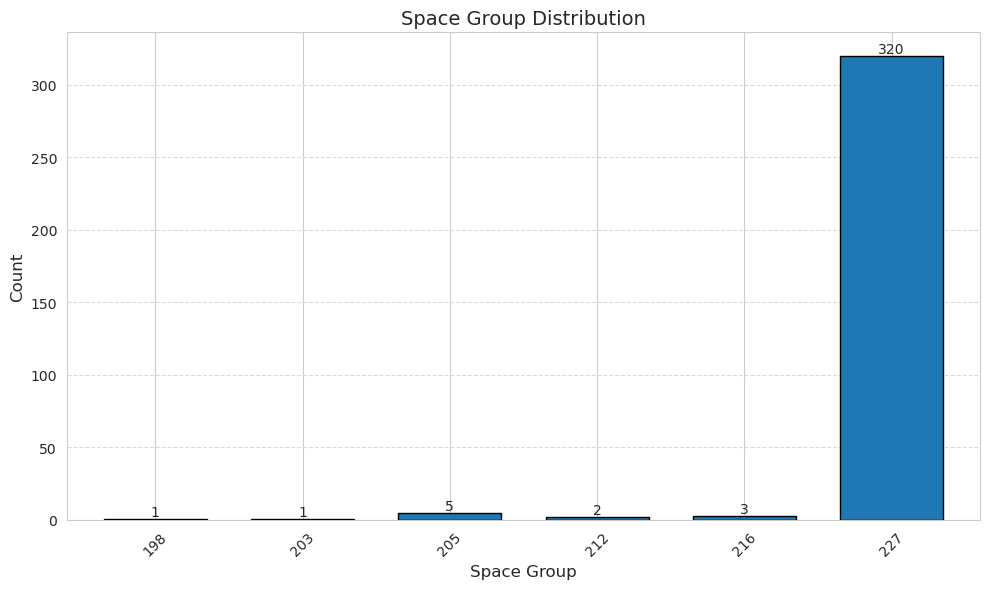

In [9]:
import matplotlib.pyplot as plt
sg_counts = materials_data['space_group'].value_counts()

sg_counts = sg_counts.sort_index() 

# --- 3. 绘制可视化图表 ---
plt.figure(figsize=(10, 6)) # 设置窗口大小

sg_counts.plot(kind='bar', color='#1f77b4', edgecolor='black', width=0.7, zorder=3)

# 设置标题和标签
plt.title('Space Group Distribution', fontsize=14)
plt.xlabel('Space Group', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 在每个柱子上方显示具体数值
for index, value in enumerate(sg_counts):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)

# 优化显示细节
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.xticks(rotation=45) # 如果标签太长，可以旋转角度
plt.tight_layout()      # 自动调整布局，防止标签被遮挡

plt.show()

In [10]:
df_227 = materials_data[materials_data['space_group'] == 227]

In [11]:
df_227.to_csv('/home/gaotianjiao/modnet-master/ext_struc/spinels.csv')

In [12]:
import os
import pandas as pd
from mp_api.client import MPRester

def download_cif_from_ids(apikey, csv_path, save_dir="./spinels_cif"):
    if not os.path.exists(csv_path):
        print(f"❌ 未找到文件: {csv_path}")
        return

    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    if "id" not in df.columns:
        print("❌ CSV 中没有 'id' 列！请确保已包含材料 ID（mp-xxxx）。")
        return

    ids = df["id"].dropna().unique().tolist()
    print(f"🔍 共检测到 {len(ids)} 个材料 ID，将开始下载...")

    with MPRester(apikey) as m:
        # 检查可用接口（不同版本 mp_api 兼容）
        has_materials_structure = hasattr(m.materials, "structure")
        has_structures = hasattr(m, "structures")
        has_get_structure = hasattr(m, "get_structure_by_material_id")

        for mid in ids:
            cif_path = os.path.join(save_dir, f"{mid}.cif")
            if os.path.exists(cif_path):
                print(f"已存在: {cif_path}")
                continue

            try:
                if has_materials_structure:
                    structure_doc = m.materials.structure.get(mid, conventional_unit_cell=True)
                    structure = structure_doc.structure
                elif has_structures:
                    structure_doc = m.structures.get_data_by_id(mid)
                    structure = structure_doc[0].structure
                elif has_get_structure:
                    structure = m.get_structure_by_material_id(mid)
                else:
                    raise RuntimeError("未找到合适的结构接口，请更新 mp_api 包。")

                cif_str = structure.to(fmt="cif")
                with open(cif_path, "w") as f:
                    f.write(cif_str)
                print(f"✅ 已保存 CIF: {cif_path}")

            except Exception as e:
                print(f"❌ 下载失败 {mid}: {e}")

    print("全部下载完成！")

if __name__ == "__main__":
    API_KEY = "7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp"  
    CSV_PATH = "/home/gaotianjiao/modnet-master/ext_struc/spinels.csv"
    SAVE_DIR = "/home/gaotianjiao/modnet-master/ext_struc/spinels_cif"

    download_cif_from_ids(API_KEY, CSV_PATH, SAVE_DIR)

🔍 共检测到 320 个材料 ID，将开始下载...


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 已保存 CIF: /home/gaotianjiao/modnet-master/ext_struc/spinels_cif/mp-1238886.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 已保存 CIF: /home/gaotianjiao/modnet-master/ext_struc/spinels_cif/mp-1389421.cif


...

✅ 已保存 CIF: /home/gaotianjiao/modnet-master/ext_struc/spinels_cif/mp-35475.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 已保存 CIF: /home/gaotianjiao/modnet-master/ext_struc/spinels_cif/mp-758452.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 已保存 CIF: /home/gaotianjiao/modnet-master/ext_struc/spinels_cif/mp-754446.cif
全部下载完成！


In [1]:
import os
from mp_api.client import MPRester

# 设置你的Materials Project API Key
api_key = "7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp"  
mpr = MPRester(api_key)

# 获取材料的结构信息
structure = mpr.get_structure_by_material_id("mp-998786")

# 定义保存路径
output_dir = "/home/gaotianjiao/modnet-master/ext_struc/perovskite_cifs"
output_file = os.path.join(output_dir, "mp-998786.cif")

# 如果目录不存在，创建目录
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 保存为CIF文件
structure.to(fmt="cif", filename=output_file)
print(f"CIF文件已保存到：{output_file}")

/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

CIF文件已保存到：/home/gaotianjiao/modnet-master/ext_struc/perovskite_cifs/mp-998786.cif


# 钙钛矿数据获取

In [1]:
import pandas as pd

# 1. 读取两个 CSV 文件
df_oxide = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/oxide.csv')
df_halide = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/halide.csv')

df_combined = pd.concat([df_oxide, df_halide], ignore_index=True, sort=False)

print(f"Oxide shape: {df_oxide.shape}")
print(f"Halide shape: {df_halide.shape}")
print(f"Combined shape: {df_combined.shape}")


Oxide shape: (1043, 224)
Halide shape: (1630, 225)
Combined shape: (2673, 244)


In [2]:
df_combined.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Formula', 'space_group', 'lattice_a',
       'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta',
       'lattice_gamma',
       ...
       'Ionic radius (Å)_A/Ionic radius (Å)_X',
       'Ionic radius (Å)_A/Ionic radius (Å)_Y',
       'Ionic radius (Å)_X/Ionic radius (Å)_Y', 'Ionic radius (Å)_A^2',
       'Ionic radius (Å)_X^2', 'Ionic radius (Å)_Y^2',
       '(Ionic radius (Å)_A-Ionic radius (Å)_X)^2',
       '(Ionic radius (Å)_A-Ionic radius (Å)_Y)^2',
       '(Ionic radius (Å)_X-Ionic radius (Å)_Y)^2',
       'Ionic radius (Å)_A*Ionic radius (Å)_X*Ionic radius (Å)_Y'],
      dtype='object', length=244)

In [3]:
df_final = df_combined.loc[:, :'mat_type']

print("筛选后的列名:", df_final.columns.tolist())
print(f"最终数据形状: {df_final.shape}")

筛选后的列名: ['Unnamed: 0.1', 'Unnamed: 0', 'Formula', 'space_group', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'elements', 'nsite', 'volume', 'density', 'formation_energy_per_atom', 'band_gap', 'possible_species', 'A_valence', 'X_valence', 'Y_valence', 'Ionic radius (Å)_A', 'Ionic radius (Å)_X', 'Ionic radius (Å)_Y', 'Mulliken EN_A', 'Mulliken EN_X', 'Mulliken EN_Y', 'Number of valence electrons_A', 'Number of valence electrons_X', 'Number of valence electrons_Y', 'Electronegativity_A', 'Electronegativity_X', 'Electronegativity_Y', 'Number of s electrons_A', 'Number of s electrons_X', 'Number of s electrons_Y', 'Number of p electrons_A', 'Number of p electrons_X', 'Number of p electrons_Y', 'Number of d electrons_A', 'Number of d electrons_X', 'Number of d electrons_Y', 'Number of outer shell electrons_A', 'Number of outer shell electrons_X', 'Number of outer shell electrons_Y', 'Cohesive energy (eV)_A', 'Cohesive energy (eV)_X', 'Cohesive ene

In [4]:
t_col = 'Goldschmidt Tolerance Factor (t)'

df = df_final[(df_final[t_col] >= 0.77) & (df_final[t_col] <= 1.1)]

# --- 检查结果 ---
print(f"筛选前的数据量: {len(df_final)}")
print(f"筛选后的数据量: {len(df)}")
print("-" * 30)

筛选前的数据量: 2673
筛选后的数据量: 2224
------------------------------


In [6]:
import os
import pandas as pd
from mp_api.client import MPRester # 注意这里改用了新版客户端
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

MAPI_KEY = "7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp" 

output_dir = "/home/gaotianjiao/modnet-master/ext_struc/perovskite_cif"
os.makedirs(output_dir, exist_ok=True)

def download_conventional_cif(row, mpr):
    formula = row['Formula'] 

    target_sg = int(row['space_group'])
    
    print(f"正在搜索: {formula} (Space Group: {target_sg})...")
    
    try:

        docs = mpr.materials.summary.search(
            formula=formula, 
            fields=["material_id", "symmetry", "structure"] # 新版字段名略有不同
        )
        
        found = False
        for doc in docs:

            if doc.symmetry.number == target_sg:
                found = True
                mp_id = doc.material_id
                structure = doc.structure

                sga = SpacegroupAnalyzer(structure)
                conventional_structure = sga.get_conventional_standard_structure()

                filename = f"{mp_id}.cif"
                filepath = os.path.join(output_dir, filename)
                
                # 保存
                conventional_structure.to(filename=filepath)
                print(f"  -> 已保存: {filename}")
        
        if not found:
            print(f"  -> 未在数据库中找到匹配 Space Group {target_sg} 的 {formula}")

    except Exception as e:
        print(f"  -> 处理 {formula} 时出错: {e}")


if 'df' in locals():
    # 建立连接
    with MPRester(MAPI_KEY) as mpr:
        for index, row in df.iterrows():
            download_conventional_cif(row, mpr)
            
    print(f"\n所有任务完成。文件保存至: {output_dir}")
else:
    print("错误: 找不到变量 'df'。请确保您已经读取了 CSV 文件。")

正在搜索: CaZrO3 (Space Group: 221)...


Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

  -> 已保存: mp-542112.cif
正在搜索: CeTiO3 (Space Group: 221)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

  -> 已保存: mp-754524.cif
正在搜索: BaTaO3 (Space Group: 221)...


...

  -> 已保存: mp-1114229.cif
正在搜索: Rb2NaYbF6 (Space Group: 225)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

  -> 已保存: mp-1205802.cif
正在搜索: Rb2TlHgI6 (Space Group: 225)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

  -> 已保存: mp-1114194.cif

所有任务完成。文件保存至: /home/gaotianjiao/modnet-master/ext_struc/perovskite_cif
